# Example: Single-Frequency Topology Optimization

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

jax.config.update("jax_enable_x64", True)

from fluxmax.optimization.design_tools import dielectric_eps_from_density, project_tanh
from fluxmax.parallelism import VALID_MODES, compute_bz_average, flatten_k_points
from fluxmax.physics import heat_transfer as ht
from fluxmax.physics.kernels import broadcast_slab_permittivity, make_two_body_bz_kernel
from fluxmax.setup import two_body as tb
from fluxmax.utils.plot_utils import plot_square_bz_points

print("JAX devices:", jax.devices())
print("Execution modes:", sorted(VALID_MODES))

JAX devices: [CudaDevice(id=0)]
Execution modes: ['multi_device_chunked', 'single_device_chunked', 'single_device_direct']


Actual Fourier terms: 97
Selected execution mode: single_device_chunked
k_chunk_size: 1
omega_chunk_size: 1
omega: 6.283185


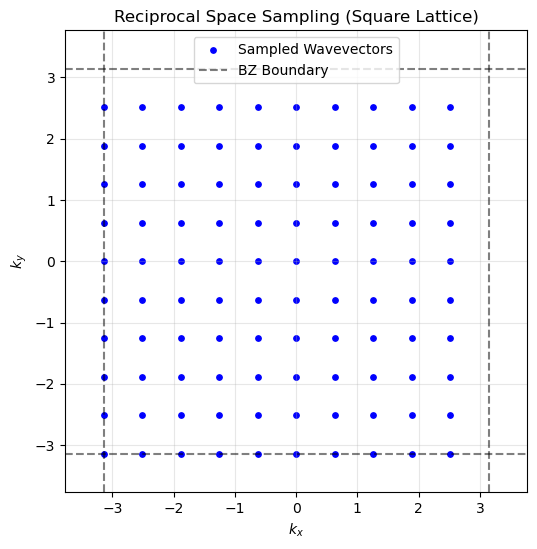

In [ ]:
WAVELENGTH = 1.0
PITCH = 1.0
SLAB_THICKNESS = 0.5
GAP = 0.5
TEMP_A = 1.0
TEMP_B = 2.0
EPS_VOID = 1.0 + 0.0j
EPS_SOLID = 10.0 + 0.01j
APPROXIMATE_NUM_TERMS = 100
BZ_GRID = (10, 10)
DESIGN_N = 64
EXECUTION_MODE = "single_device_chunked"
OMEGA_CHUNK_SIZE = 1
K_CHUNK_SIZE = 1
LEARNING_RATE = 0.05
BETA_STAGES = [0.5, 5.0, 10.0, 20.0]
ITER_STAGES = [30, 20, 20, 20]
SEED = 1

plv, expansion, in_plane_wavevector = tb.make_rcwa_setup(
    pitch=PITCH,
    approximate_num_terms=APPROXIMATE_NUM_TERMS,
    brillouin_grid_shape=BZ_GRID,
)
k_points = flatten_k_points(in_plane_wavevector)
N_BZ = int(k_points.shape[0])
AREA = tb.cell_area(plv)
OMEGA = jnp.asarray(ht.wavelength_to_omega(jnp.asarray(WAVELENGTH)))
RESOLUTION = PITCH / DESIGN_N
N_DEVICES = len(jax.devices())

print(f"Actual Fourier terms: {expansion.num_terms}")
print(f"Selected execution mode: {EXECUTION_MODE}")
print(f"k_chunk_size: {K_CHUNK_SIZE}")
print(f"omega_chunk_size: {OMEGA_CHUNK_SIZE}")
print(f"omega: {float(OMEGA):.6f}")

fig = plot_square_bz_points(in_plane_wavevector, PITCH)

In [ ]:
kernel = make_two_body_bz_kernel(
    primitive_lattice_vectors=plv,
    expansion=expansion,
    slab_thickness=SLAB_THICKNESS,
    gap=GAP,
    eps_gap=EPS_VOID,
)

def design_shape() -> tuple[int, int]:
    return (DESIGN_N, DESIGN_N)

def projected_density_and_eps(rho: jnp.ndarray, beta: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    rho_hat = project_tanh(rho, beta)
    eps_grid = dielectric_eps_from_density(
        rho=rho_hat,
        eps_solid=EPS_SOLID,
        eps_void=EPS_VOID,
    )
    return rho_hat, eps_grid

def dispatcher_kwargs(execution_mode: str) -> dict[str, int | str | None]:
    return {
        "execution_mode": execution_mode,
        "k_chunk_size": K_CHUNK_SIZE,
        "omega_chunk_size": OMEGA_CHUNK_SIZE,
    }

def bz_average_tau(permittivity_2d: jnp.ndarray, execution_mode: str = EXECUTION_MODE) -> jnp.ndarray:
    tau_avg = compute_bz_average(
        kernel_fn=kernel,
        omega_1d=jnp.asarray([OMEGA]),
        eps_omega=broadcast_slab_permittivity(permittivity_2d, 1),
        k_points=k_points,
        **dispatcher_kwargs(execution_mode),
    )
    return tau_avg[0]

def net_spectral_flux_per_area(rho: jnp.ndarray, beta: jnp.ndarray, execution_mode: str = EXECUTION_MODE) -> jnp.ndarray:
    _, eps_grid = projected_density_and_eps(rho, beta)
    tau_bz_avg = bz_average_tau(eps_grid, execution_mode=execution_mode)
    theta_A = ht.bose_einstein(OMEGA, jnp.asarray(TEMP_A))
    theta_B = ht.bose_einstein(OMEGA, jnp.asarray(TEMP_B))
    net_prefactor = OMEGA * (theta_B - theta_A)
    return net_prefactor * tau_bz_avg / AREA

def loss(rho: jnp.ndarray, beta: jnp.ndarray) -> jnp.ndarray:
    return -net_spectral_flux_per_area(rho, beta)

loss_and_grad = jax.jit(jax.value_and_grad(loss))

rho0 = jax.random.uniform(jax.random.key(SEED), design_shape())
beta0 = jnp.asarray(BETA_STAGES[0])
initial_flux = float(net_spectral_flux_per_area(rho0, beta0))
print(f"Initial mirror-symmetric net flux / area: {initial_flux:.6e}")

Initial mirror-symmetric net flux / area: 1.656270e-01


## Optimization with Optax

In [ ]:
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(rho0)
rho = rho0
history = {"step": [], "beta": [], "net_flux": [], "loss": []}

step = 0
print(f"{'Step':>5}  {'beta':>6}  {'net flux / area':>16}")
print("-" * 38)
for stage_beta, stage_steps in zip(BETA_STAGES, ITER_STAGES):
    beta = jnp.asarray(stage_beta)
    for _ in range(stage_steps):
        loss_value, grads = loss_and_grad(rho, beta)
        updates, opt_state = optimizer.update(grads, opt_state, rho)
        rho = optax.apply_updates(rho, updates)

        net_flux = float(-loss_value)
        history["step"].append(step)
        history["beta"].append(float(beta))
        history["net_flux"].append(net_flux)
        history["loss"].append(float(loss_value))

        if step % 5 == 0 or step == sum(ITER_STAGES) - 1:
            print(f"{step:>5}  {float(beta):>6.2f}  {net_flux:>16.6e}")
        step += 1

beta_final = jnp.asarray(BETA_STAGES[-1])
rho_hat_final, eps_final = projected_density_and_eps(rho, beta_final)
final_net_flux = float(net_spectral_flux_per_area(rho, beta_final))

print()
print(f"Final mirror-symmetric net flux / area: {final_net_flux:.6e}")

 Step    beta   net flux / area
--------------------------------------
    0    0.50      1.656270e-01
    5    0.50      2.961860e-01
   10    0.50      3.957084e-01
   15    0.50      2.284798e-01
   20    0.50      3.596965e-01
   25    0.50      2.831516e-01
   30    5.00      1.981726e-01
   35    5.00      1.590280e-01
   40    5.00      2.134637e-01
   45    5.00      3.023945e-01
   50   10.00      2.518521e-01
   55   10.00      3.593111e-01
   60   10.00      2.738039e-01
   65   10.00      2.869362e-01
   70   20.00      3.289639e-01
   75   20.00      3.936643e-01
   80   20.00      4.258688e-01
   85   20.00      4.205232e-01
   89   20.00      4.305452e-01

Final mirror-symmetric net flux / area: 4.349451e-01


## Results

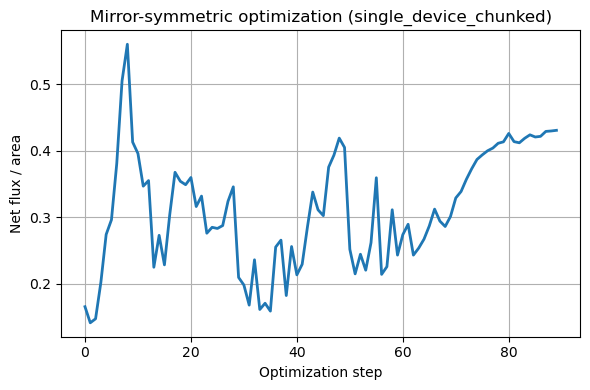

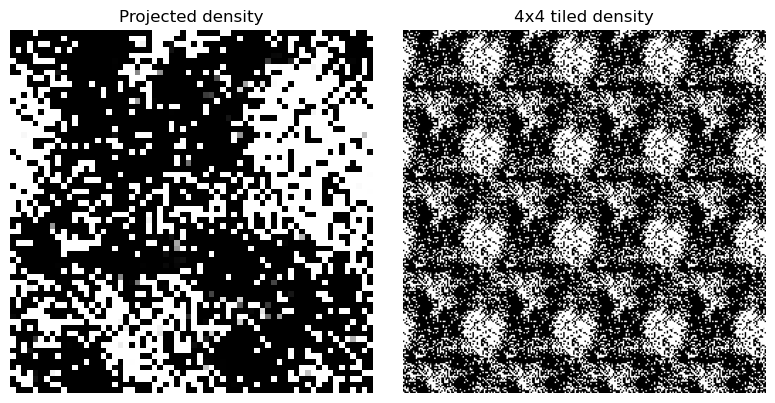

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["step"], history["net_flux"], linewidth=2)
plt.xlabel("Optimization step")
plt.ylabel("Net flux / area")
plt.title(f"Mirror-symmetric optimization ({EXECUTION_MODE})")
plt.grid(True)
plt.tight_layout()
plt.show()

tile_factor = 4
rho_np = np.asarray(rho_hat_final)
eps_np = np.real(np.asarray(eps_final))
fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
axes = axes[0]
axes[0].imshow(rho_np, origin="lower", cmap="binary", vmin=0, vmax=1)
axes[0].set_title("Projected density")
axes[0].axis("off")
axes[1].imshow(np.tile(rho_np, (tile_factor, tile_factor)), origin="lower", cmap="binary", vmin=0, vmax=1)
axes[1].set_title(f"{tile_factor}x{tile_factor} tiled density")
axes[1].axis("off")
plt.tight_layout()
plt.show()